In [1]:
import pandas as pd

# Adjust path to your dataset
file_path = "data/dataset_TSMC2014_NYC.txt"

# Load as tab-separated file
cols = [
    "userID",
    "venueID",
    "categoryID",
    "categoryName",
    "latitude",
    "longitude",
    "timezone_offset",
    "timestamp",
]

# Try with Latin-1
df = pd.read_csv(file_path, sep="\t", header=None, names=cols, encoding="latin1")

df.head(10)

,userID,venueID,categoryID,categoryName,latitude,longitude,timezone_offset,timestamp
0,470,49bbd6c0f964a520f4531fe3,4bf58dd8d48988d127951735,Arts & Crafts Store,40.719810,-74.002581,-240,Tue Apr 03 18:00:09 +0000 2012
1,979,4a43c0aef964a520c6a61fe3,4bf58dd8d48988d1df941735,Bridge,40.606800,-74.044170,-240,Tue Apr 03 18:00:25 +0000 2012
2,69,4c5cc7b485a1e21e00d35711,4bf58dd8d48988d103941735,Home (private),40.716162,-73.883070,-240,Tue Apr 03 18:02:24 +0000 2012
3,395,4bc7086715a7ef3bef9878da,4bf58dd8d48988d104941735,Medical Center,40.745164,-73.982519,-240,Tue Apr 03 18:02:41 +0000 2012
4,87,4cf2c5321d18a143951b5cec,4bf58dd8d48988d1cb941735,Food Truck,40.740104,-73.989658,-240,Tue Apr 03 18:03:00 +0000 2012
5,484,4b5b981bf964a520900929e3,4bf58dd8d48988d118951735,Food & Drink Shop,40.690427,-73.954687,-240,Tue Apr 03 18:04:00 +0000 2012
6,642,4ab966c3f964a5203c7f20e3,4bf58dd8d48988d1e0931735,Coffee Shop,40.751591,-73.974121,-240,Tue Apr 03 18:04:38 +0000 2012
7,292,4d0cc47f903d37041864bf55,4bf58dd8d48988d12b951735,Bus Station,40.779422,-73.955341,-240,Tue Apr 03 18:04:42 +0000 2012
8,428,4ce1863bc4f6a35d8bd2db6c,4bf58dd8d48988d103941735,Home (private),40.619151,-74.035888,-240,Tue Apr 03 18:06:18 +0000 2012
9,877,4be319b321d5a59352311811,4bf58dd8d48988d10a951735,Bank,40.619006,-73.990375,-240,Tue Apr 03 18:06:19 +0000 2012


In [2]:
food = ["Food", "Restaurant", "Bar", "Café", "Food Truck"]
shop = ["Shop", "Store", "Market", "Mall"]
entertain = ["Arts", "Theater", "Cinema", "Stadium", "Bridge", "Park"]


def assign_group(cat):
    for kw in food:
        if kw.lower() in cat.lower():
            return "Food/Drink"
    for kw in shop:
        if kw.lower() in cat.lower():
            return "Shop/Service"
    for kw in entertain:
        if kw.lower() in cat.lower():
            return "Entertainment/Travel"
    return "Other"


df["group"] = df["categoryName"].apply(assign_group)

print(df["group"].value_counts())

group
Other                   139794
Food/Drink               46582
Shop/Service             29065
Entertainment/Travel     11987
Name: count, dtype: int64


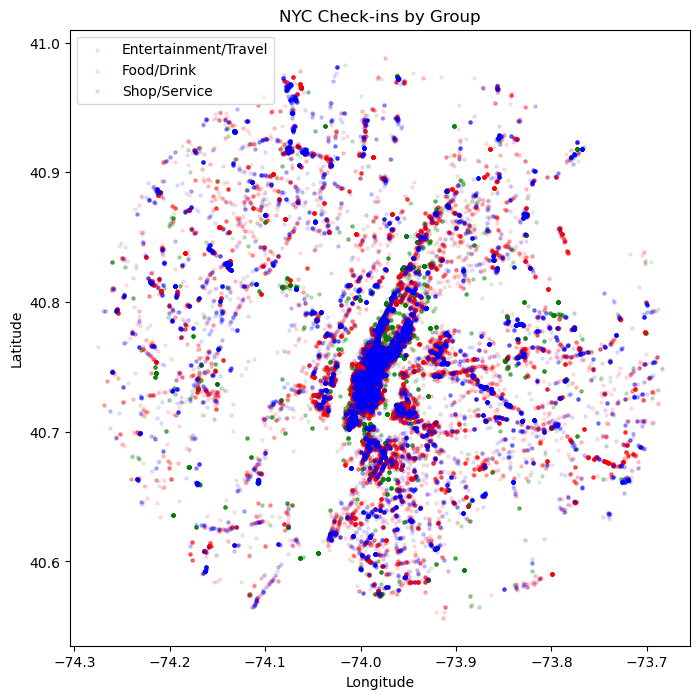

In [3]:
import matplotlib.pyplot as plt

# Filter out "Other"
plot_df = df[df["group"] != "Other"]

colors = {"Food/Drink": "red", "Shop/Service": "blue", "Entertainment/Travel": "green"}

plt.figure(figsize=(8, 8))
for g, gdf in plot_df.groupby("group"):
    plt.scatter(
        gdf["longitude"], gdf["latitude"], s=5, alpha=0.1, label=g, color=colors[g]
    )

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("NYC Check-ins by Group")
plt.legend()
plt.show()
